C:\Users\SWARA LAKSHMI J\AppData\Local\Temp\ipykernel_20556\477049849.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (pca_df.PC1[i], pca_df.PC2[i]), size=8, xytext=(5, 2), textcoords='offset points')


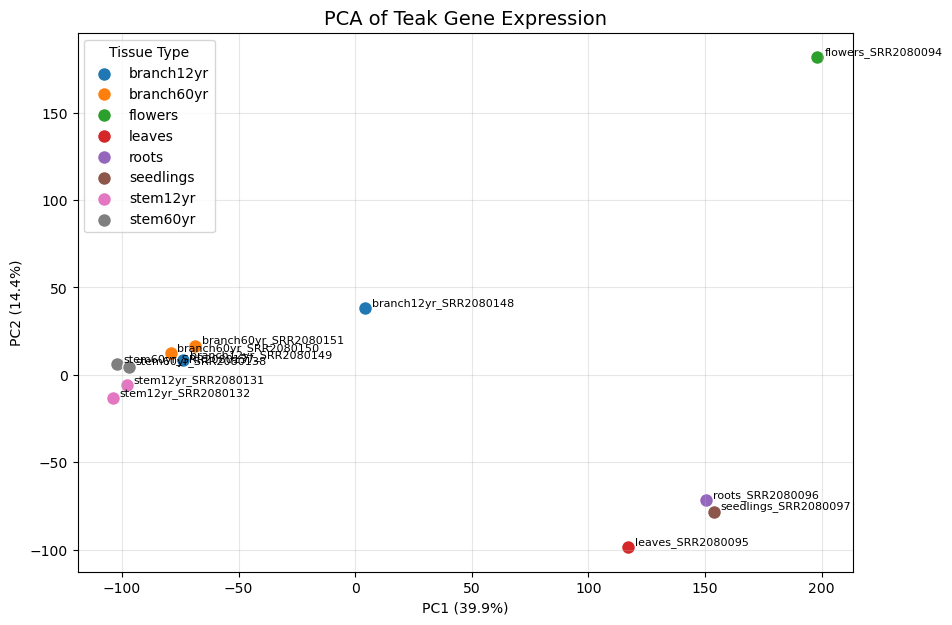

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the cleaned data
df = pd.read_excel('EXPRESSION_GENETeak_Cleaned_Data_Final.xlsx', index_col=0)

# 2. Transpose (Samples = Rows, Genes = Columns)
df_t = df.T

# 3. Standard Scaling
# PCA is sensitive to the scale of features; scaling ensures all genes contribute equally.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_t)

# 4. Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create a plotting DataFrame
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=df_t.index)
pca_df['Tissue'] = [idx.split('_')[0] for idx in pca_df.index]

# 5. Visualize with Matplotlib
plt.figure(figsize=(10, 7))
for tissue in pca_df['Tissue'].unique():
    subset = pca_df[pca_df['Tissue'] == tissue]
    plt.scatter(subset['PC1'], subset['PC2'], label=tissue, s=100, edgecolors='white')

# Add labels for each sample
for i, txt in enumerate(pca_df.index):
    plt.annotate(txt, (pca_df.PC1[i], pca_df.PC2[i]), size=8, xytext=(5, 2), textcoords='offset points')

plt.title('PCA of Teak Gene Expression', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(title='Tissue Type')
plt.grid(alpha=0.3)
plt.savefig('pca_result.png')
plt.show()

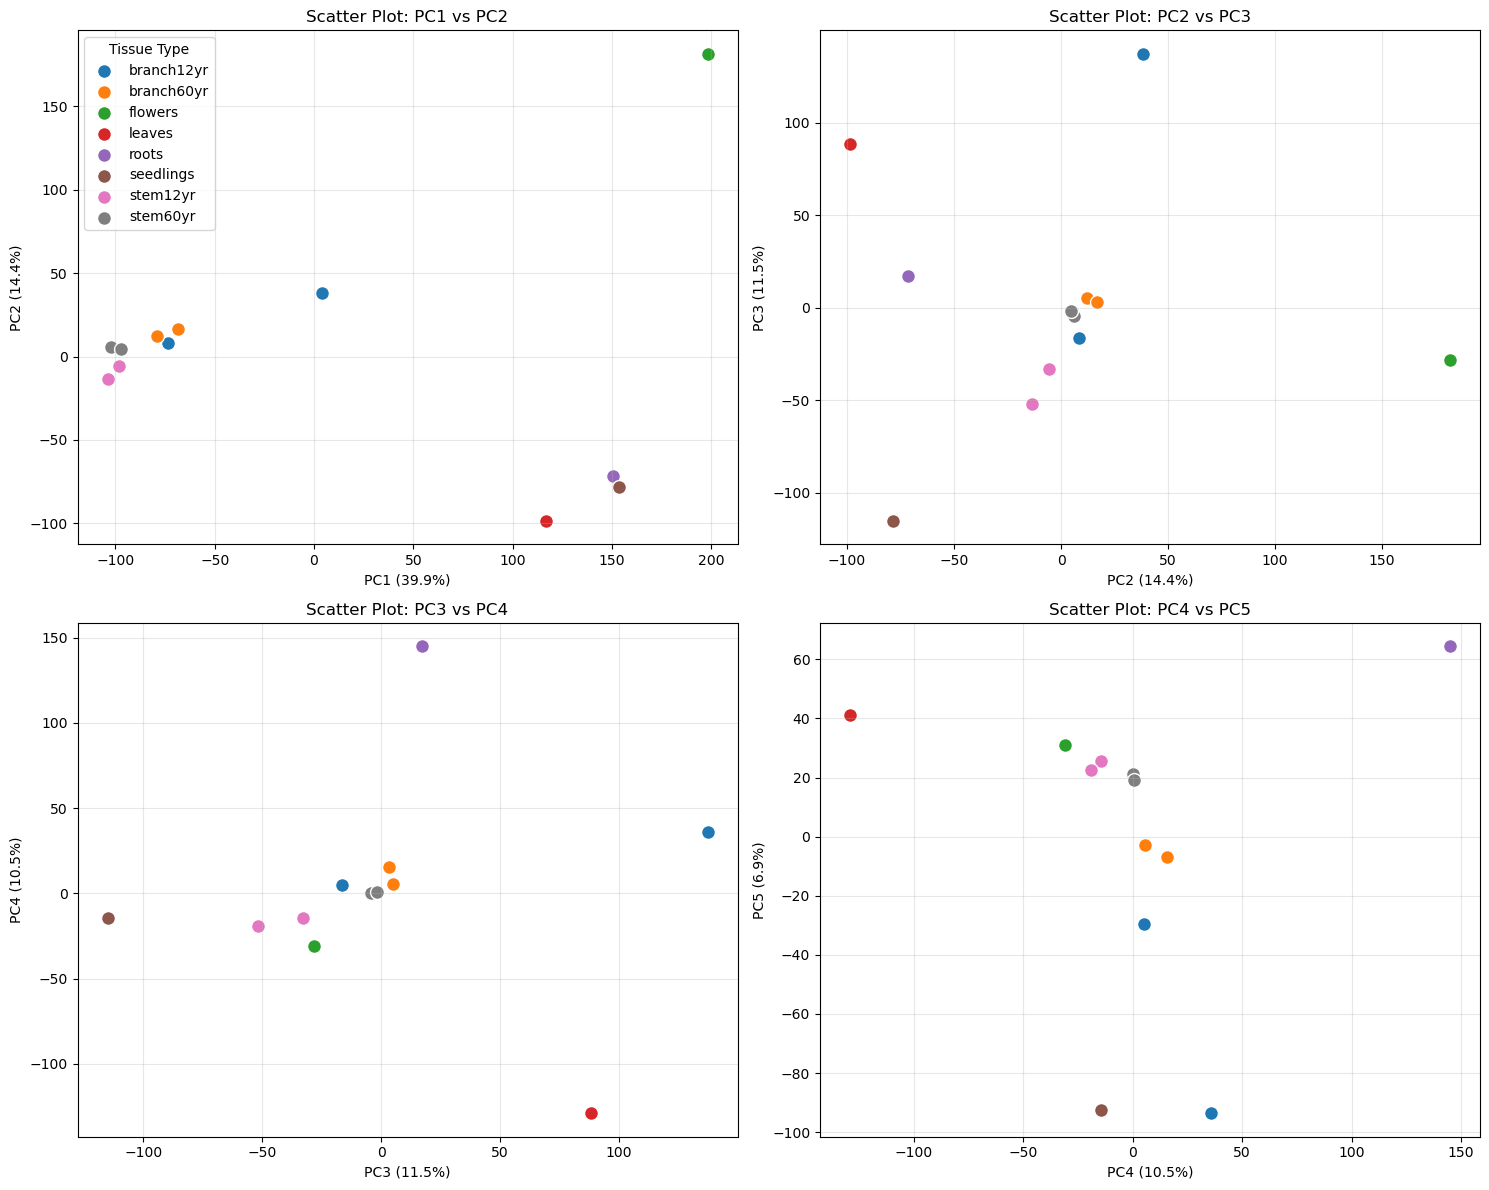

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the data
df = pd.read_excel('EXPRESSION_GENETeak_Cleaned_Data_Final.xlsx', index_col=0)
df_t = df.T

# 2. Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_t)

# 3. Run PCA with 5 components
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)

# Create a results DataFrame
pc_cols = [f'PC{i+1}' for i in range(5)]
pca_df = pd.DataFrame(pca_result, columns=pc_cols, index=df_t.index)
pca_df['Tissue'] = [idx.split('_')[0] for idx in pca_df.index]

# 4. Create Scatter Plots for PC pairs
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Define the pairs to plot
pairs = [('PC1', 'PC2'), ('PC2', 'PC3'), ('PC3', 'PC4'), ('PC4', 'PC5')]

for i, (pc_x, pc_y) in enumerate(pairs):
    ax = axes[i]
    for tissue in pca_df['Tissue'].unique():
        subset = pca_df[pca_df['Tissue'] == tissue]
        ax.scatter(subset[pc_x], subset[pc_y], label=tissue, s=100, edgecolors='white')
    
    # Add titles and labels with variance percentage
    idx_x = int(pc_x[2:]) - 1
    idx_y = int(pc_y[2:]) - 1
    ax.set_title(f'Scatter Plot: {pc_x} vs {pc_y}', fontsize=12)
    ax.set_xlabel(f'{pc_x} ({pca.explained_variance_ratio_[idx_x]:.1%})')
    ax.set_ylabel(f'{pc_y} ({pca.explained_variance_ratio_[idx_y]:.1%})')
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.legend(title='Tissue Type', loc='best')

plt.tight_layout()
plt.savefig('teak_pca_5_scatters.png')
plt.show()

<Figure size 1500x1500 with 0 Axes>

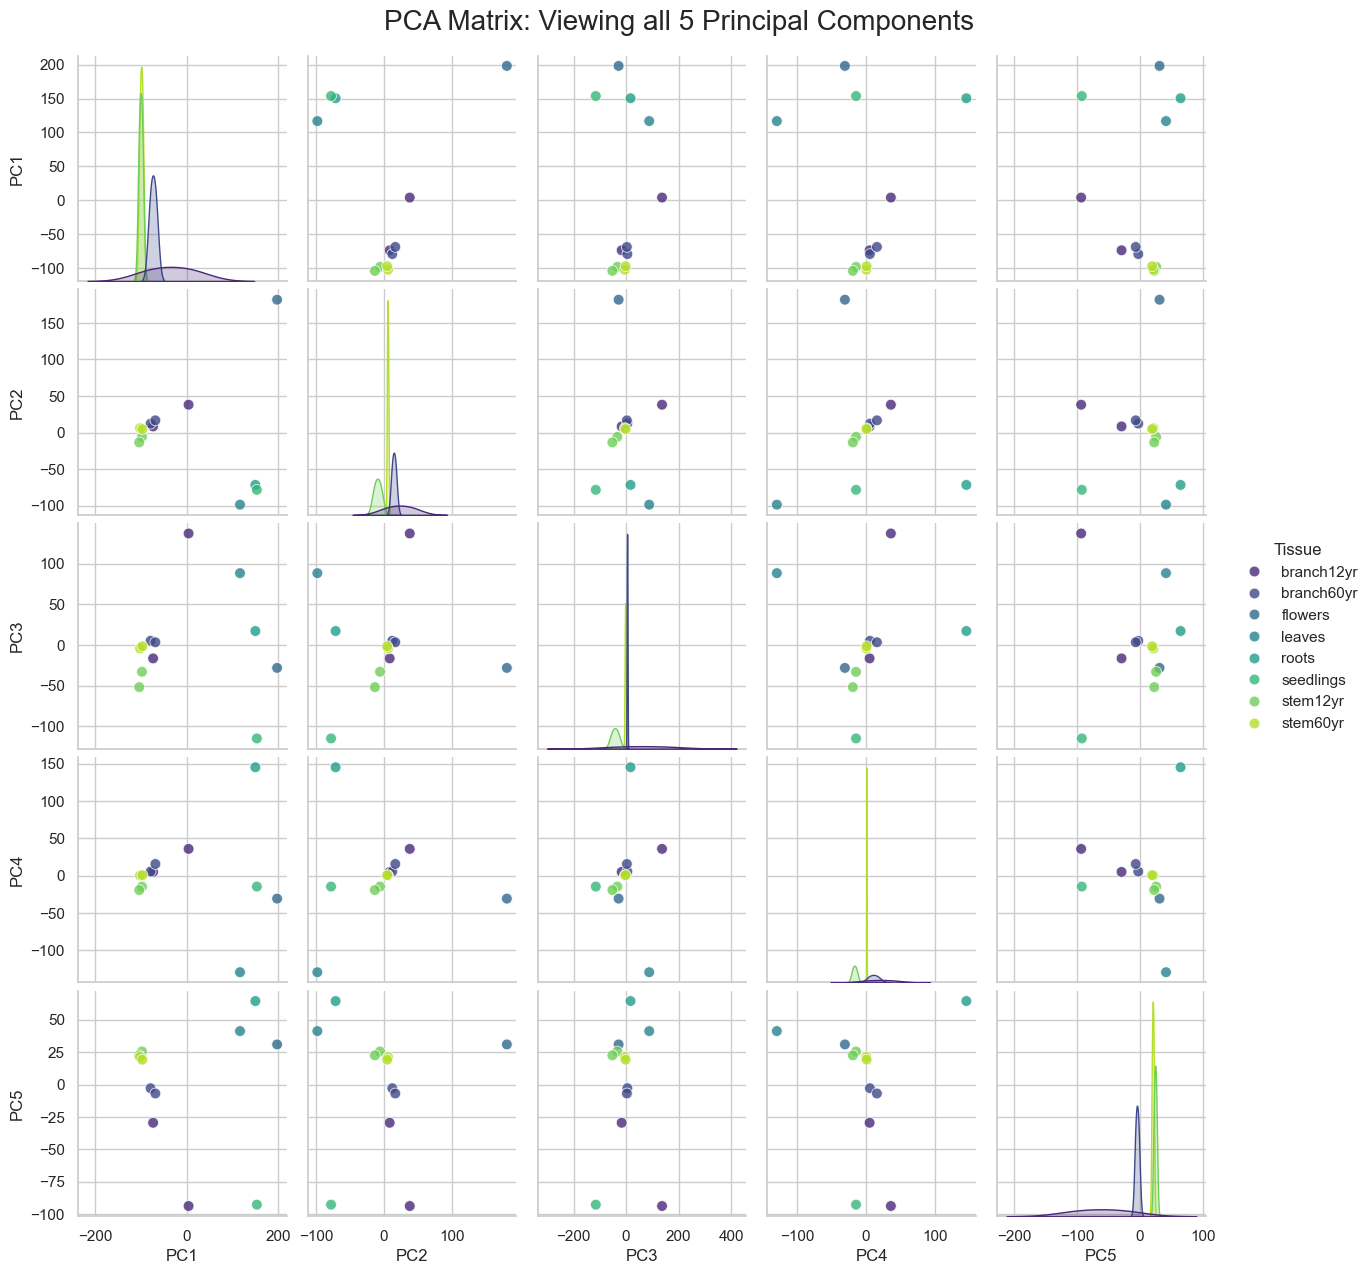

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the data
df = pd.read_excel('EXPRESSION_GENETeak_Cleaned_Data_Final.xlsx', index_col=0)
df_t = df.T

# 2. Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_t)

# 3. PCA for exactly 5 components
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)

# 4. Create a DataFrame for all 5 components
pc_cols = [f'PC{i+1}' for i in range(5)]
pca_df = pd.DataFrame(pca_result, columns=pc_cols, index=df_t.index)
pca_df['Tissue'] = [idx.split('_')[0] for idx in pca_df.index]

# 5. The "Full Matrix" Plot
# This will show you PC1, PC2, PC3, PC4, and PC5 all at once
plt.figure(figsize=(15, 15))
sns.set(style="whitegrid")
g = sns.pairplot(pca_df, hue='Tissue', palette='viridis', 
                 diag_kind='kde', plot_kws={'s':60, 'alpha':0.8})

g.fig.suptitle('PCA Matrix: Viewing all 5 Principal Components', y=1.02, fontsize=20)

# Save the dashboard
plt.savefig('pca_5_component_dashboard.png', dpi=300)
plt.show()

# Save the numeric coordinates for your records
pca_df.to_csv('teak_pca_5_coordinates.csv')

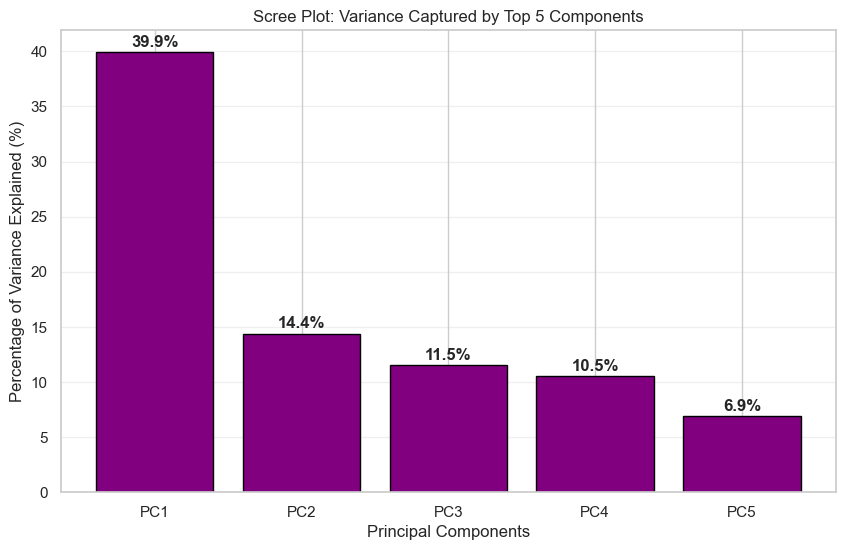

PCA 5-components saved to 'teak_pca_5_components.csv'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the cleaned data
df = pd.read_excel('EXPRESSION_GENETeak_Cleaned_Data_Final.xlsx', index_col=0)

# 2. Transpose (Samples = Rows, Genes = Columns)
df_t = df.T

# 3. Standard Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_t)

# 4. Run PCA for 5 components
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)

# Create a DataFrame to store the 5 components
pc_columns = [f'PC{i+1}' for i in range(5)]
pca_df = pd.DataFrame(pca_result, columns=pc_columns, index=df_t.index)

# 5. Visualization: Scree Plot (Variance Explained)
plt.figure(figsize=(10, 6))
plt.bar(pc_columns, pca.explained_variance_ratio_ * 100, color='purple', edgecolor='black')
plt.xlabel('Principal Components')
plt.ylabel('Percentage of Variance Explained (%)')
plt.title('Scree Plot: Variance Captured by Top 5 Components')

# Add percentage labels on top of bars
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.savefig('pca_scree_plot.png')
plt.show()

# 6. Save the 5-component results for Machine Learning
pca_df.to_csv('teak_pca_5_components.csv')
print("PCA 5-components saved to 'teak_pca_5_components.csv'")